In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from scipy.stats import bernoulli
from scipy.stats import bernoulli, chi2_contingency

#### Bernoulli Distribution

<table align="left">
  <tr>
    <th align="left"><b>Aspect</b></th>
    <th align="left"><b>Details</b></th>
  </tr>
  <tr>
    <td align="left"><b>What it models</b></td>
    <td align="left">Single binary outcome (coin flip: heads/tails, 1/0)</td>
  </tr>
  <tr>
    <td align="left"><b>Key parameter</b></td>
    <td align="left"><i>p</i> = probability of success (e.g., <i>p</i> = 0.7 means 70% chance of 1)</td>
  </tr>
  <tr>
    <td align="left"><b>ML hook</b></td>
    <td align="left">Every binary classifier's output is an estimated Bernoulli parameter <i>p̂</i></td>
  </tr>
  <tr>
    <td align="left"><b>Math to know</b></td>
    <td align="left">Mean = <i>p</i>, Variance = <i>p</i>(1 − <i>p</i>)</td>
  </tr>
</table>

<table align="left">
  <tr>
    <th align="left">Concept</th>
    <th align="left">Formula</th>
    <th align="left">Meaning</th>
  </tr>
  <tr>
    <td align="left">Probability Mass Function (PMF)</td>
    <td align="left">$P(X=1) = p$, $P(X=0) = 1-p$</td>
    <td align="left">Only two possible outcomes</td>
  </tr>
  <tr>
    <td align="left">Expected Value (Mean)</td>
    <td align="left">$\mu = p$</td>
    <td align="left">The average outcome over many trials</td>
  </tr>
  <tr>
    <td align="left">Variance</td>
    <td align="left">$\sigma^2 = p(1-p)$</td>
    <td align="left">Spread of the distribution</td>
  </tr>
  <tr>
    <td align="left">Notation</td>
    <td align="left">$X \sim \text{Bernoulli}(p)$</td>
    <td align="left">"$X$ follows a Bernoulli distribution with success probability $p$"</td>
  </tr>
</table>

In [3]:
# Create custom seaborn style
custom_style = {
    'axes.facecolor': '#9fc6c7',
    'figure.facecolor': '#86a2a3',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.linewidth': 0.5,
    'grid.color': 'white',
    
    # Font settings - make text solid and dark
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'Calibri', 

    # **Fix transparency/color issues**
    'text.color': 'black',           # Make all text solid black
    'axes.labelcolor': 'black',      # Axis labels black
    'xtick.color': 'black',          # Tick marks black
    'ytick.color': 'black',          # Tick marks black
    'axes.edgecolor': 'black',       # Axes spines black
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    
}

print_rep = 50

sns.set_style('darkgrid', rc=custom_style)

Mean: 0.297 (should be ~ 0.3)
Sample variance: 0.209 (should be ~ 0.210)
% of 1's: 0.297
Total samples: 1000
0s: 703 (70.3%)
1s: 297 (29.7%)


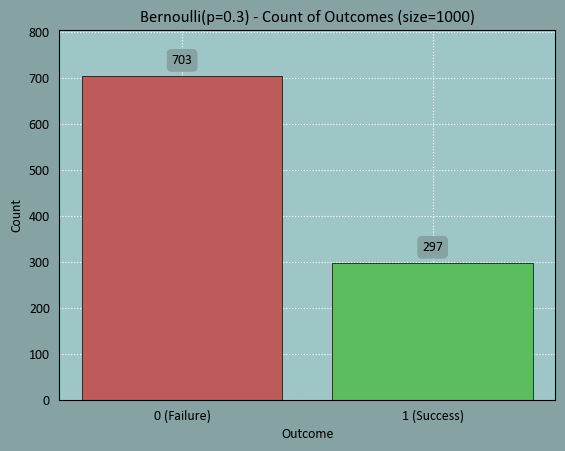

In [4]:
# Generate Bernoulli samples (coin flips)
p = 0.3 # 30% chance of 1
samples = np.random.binomial(1, p, size=1000)  # 1 = success, 0 = failure | n is the number of trials

# Verification of sample
print("=" * print_rep)
print(f"Mean: {samples.mean():.3f} (should be ~ {p})")
print(f"Sample variance: {samples.var():.3f} (should be ~ {p*(1-p):.3f})")
print(f"% of 1's: {samples.sum()/samples.size:.3f}") # the proportion of 1's to all
print("=" * print_rep)

# Plot
count_0 = (samples == 0).sum()
count_1 = (samples == 1).sum()
ylim = max(count_0, count_1) + 100

plt.bar(x=[0, 1], height=[count_0, count_1], color=["#bd5b5b", "#5bbd5f"], edgecolor='black', linewidth=0.5)
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title(f"Bernoulli(p={p}) - Count of Outcomes (size={len(samples)})")
plt.xticks([0, 1], ["0 (Failure)", "1 (Success)"])
plt.text(0, count_0 + 20, f"{count_0}", 
         ha="center", va="bottom", 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='#86a2a3', edgecolor='#86a2a3'))
plt.text(1, count_1 + 20, f"{count_1}", 
         ha="center", va="bottom", 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='#86a2a3', edgecolor='#86a2a3'))
plt.ylim(top=ylim)

print(f"Total samples: {len(samples)}")
print(f"0s: {count_0} ({count_0/len(samples):.1%})")
print(f"1s: {count_1} ({count_1/len(samples):.1%})")
print("=" * print_rep)

### ML connection:

<table align="left">
  <tr>
    <td align="left">A logistic regression model outputs $y_{pred} = \text{sigmoid}(x)$. That number is a Bernoulli $p$ parameter.</td>
  </tr>
  <tr>
    <td align="left">Binary cross-entropy loss = $- [y \cdot \log(p) + (1-y) \cdot \log(1-p)]$ — derived directly from Bernoulli likelihood.</td>
  </tr>
  <tr>
      <td align="left">Every binary classifier outputs a Bernoulli distribution. Every binary classifier is fundamentally estimating a Bernoulli parameter 
p for each input, and the sigmoid function is the bridge between the neural network's raw outputs and a valid probability!</td>
  </tr> 
  <tr>    
  <td align="left">When a spam filter predicts 0.85, that's the Bernoulli parameter $p$ - an 85% chance the email is spam. The loss function (binary cross-  entropy) is derived directly from the Bernoulli likelihood.
  Input (email text) → Hidden Layers → [Logits] → Sigmoid → [Bernoulli p] → Decision
  </td>      
  </tr>          
  <tr>    
  <td align="left">Logistic regression predicts the parameter p of a Bernoulli distribution. The entire goal of logistic regression is to estimate the Bernoulli success probability for each input</td>      
  </tr>   
</table>

#### Neural Network

In [5]:
# Steps
email, features, logits = None, None, None
def extract_features(email): ...
def neural_network(features): ...
def sigmoid(logits): ...

# An email comes in
features = extract_features(email)  # Text → numbers
logits = neural_network(features)   # Raw score: 2.3
p = sigmoid(logits)                 # 0.909 (90.9% chance of spam)

# The model says: "This email follows a Bernoulli(p=0.909) distribution"
# Which means: 90.9% chance it's spam, 9.1% chance it's not


# Imagine these are raw outputs from a neural network
logits = np.array([2.3, -1.5, 0.0, 3.1, -0.8])

# Convert to Bernoulli parameters using sigmoid
p_values = 1 / (1 + np.exp(-logits))

# For each input, the model predicts a Bernoulli distribution
for i, (logit, p) in enumerate(zip(logits, p_values)):
    print(f"Sample {i+1}: logit={logit:4.1f} → p={p:.3f}")
    print(f"  → Bernoulli(p={p:.3f}): {p*100:.1f}% chance of class 1")

Sample 1: logit= 2.3 → p=0.909
  → Bernoulli(p=0.909): 90.9% chance of class 1
Sample 2: logit=-1.5 → p=0.182
  → Bernoulli(p=0.182): 18.2% chance of class 1
Sample 3: logit= 0.0 → p=0.500
  → Bernoulli(p=0.500): 50.0% chance of class 1
Sample 4: logit= 3.1 → p=0.957
  → Bernoulli(p=0.957): 95.7% chance of class 1
Sample 5: logit=-0.8 → p=0.310
  → Bernoulli(p=0.310): 31.0% chance of class 1


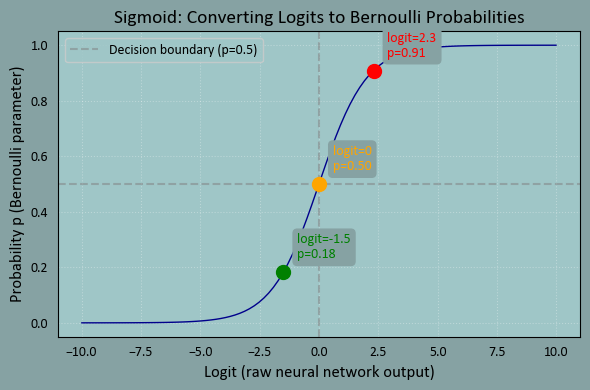

In [6]:
# Plot the sigmoid function
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sigmoid, linewidth=1, color='darkblue')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary (p=0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Logit (raw neural network output)', fontsize=12)
plt.ylabel('Probability p (Bernoulli parameter)', fontsize=12)
plt.title('Sigmoid: Converting Logits to Bernoulli Probabilities', fontsize=14)
plt.legend()

# Add some example points
for logit, color in [(2.3, 'red'), (-1.5, 'green'), (0, 'orange')]:
    p_val = 1 / (1 + np.exp(-logit))
    plt.plot(logit, p_val, 'o', color=color, markersize=10)
    plt.annotate(f'logit={logit}\np={p_val:.2f}', 
                 (logit, p_val), 
                 xytext=(10, 10), 
                 textcoords='offset points',
                 fontsize=10,
                 color=color,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='#86a2a3', edgecolor='#86a2a3'))

plt.tight_layout()
plt.show()

#### Regression

<div align="left">
  <b style="color: #00994d;">Step 1: The Assumption</b>
  <br>
  Logistic regression assumes that for given input features $X$, the target variable $y$ follows a Bernoulli distribution:
  <br><br>
  $y \mid X \sim \text{Bernoulli}(p)$
  <br><br>
  Where $p = P(y=1 \mid X)$ — the probability of class 1 given the input.
  <br><br>

  <b style="color: #00994d;">Step 2: The Problem</b>
  <br>
  We need to model $p$ as a function of $X$. But $p$ must be between 0 and 1 (it's a probability). Linear functions $w \cdot X + b$ can output any value from $-\infty$ to $+\infty$ — so we can't just say $p = w \cdot X + b$.
  <br><br>

  <b style="color: #00994d;">Step 3: The Solution (Sigmoid)</b>
  <br>
  We pass the linear function through the sigmoid function to squash it into $[0,1]$:
  <br><br>
  $p = \sigma(w \cdot X + b) = \frac{1}{1 + e^{-(w \cdot X + b)}}$
  <br><br>
  Now $p$ is a valid Bernoulli parameter.
  <br><br>

  <b style="color: #00994d;">Step 4: The Loss Function</b>
  <br>
  We want to find $w$ and $b$ that make the Bernoulli distribution fit the data. The likelihood of seeing our data is:
  <br><br>
  $\text{Likelihood} = \prod p^{y_i} \cdot (1-p)^{(1-y_i)}$
  <br><br>
  Take negative log (for minimization) and you get:
  <br><br>
  $\text{Loss} = -[y_i \cdot \log(p) + (1-y_i) \cdot \log(1-p)]$
  <br><br>
  That's binary cross-entropy loss — derived directly from the Bernoulli distribution.
</div>

In [7]:
# Simple logistic regression "by hand"
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Example data: hours studied → pass/fail
X = np.array([1, 2, 3, 4, 5, 6])  # hours studied
y = np.array([0, 0, 0, 1, 1, 1])  # 0=fail, 1=pass

# After training, logistic regression learns weights
# Let's say learned: w=1.5, b=-5.5
w, b = 1.5, -5.5

# For a student who studied 4 hours:
z = w * 4 + b  # = 1.5*4 - 5.5 = 0.5
p = sigmoid(z)  # = 0.62

# THIS IS THE KEY INSIGHT:
# The model is saying: y ~ Bernoulli(p=0.62)
# Meaning: 62% chance of passing, 38% chance of failing

print(f"For X=4 hours: P(pass=1) = {p:.3f}")
print(f"This is the Bernoulli parameter p")

# Generate predictions from this Bernoulli distribution
np.random.seed(42)
predictions = np.random.binomial(1, p, size=1000)
print(f"Out of 1000 students with 4 hours: {predictions.sum()} passed")

For X=4 hours: P(pass=1) = 0.622
This is the Bernoulli parameter p
Out of 1000 students with 4 hours: 636 passed


#### The log-odds of the Bernoulli distribution are a linear function of the inputs. (They're Identical)

In [8]:
# logistic regression and explicitly modeling Bernoulli are mathematically equivalent

# Generate data
X = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
y = np.array([0, 0, 1, 1, 1])

# Method 1: Logistic regression
lr = LogisticRegression()
lr.fit(X, y)
p_lr = lr.predict_proba([[3.5]])[0][1]

# Method 2: Manual Bernoulli MLE (what logistic regression is doing)
# The MLE for Bernoulli parameter p is just the mean of y
p_manual = np.mean(y)

print(f"Logistic Regression predicts p = {p_lr:.3f}")
print(f"Manual Bernoulli MLE gives p = {p_manual:.3f}")
# They're different because logistic regression conditions on X,
# while simple Bernoulli ignores X. But the distribution is the same!
#Logistic regression = Modeling the Bernoulli parameter p as a function of inputs using the sigmoid transformation.

Logistic Regression predicts p = 0.756
Manual Bernoulli MLE gives p = 0.600


#### A/B testing is fundamentally comparing two Bernoulli distributions

In [9]:
# You run an A/B test on a "Buy Now" button
# Version A (Blue button): 5,000 users, 500 purchases
# Version B (Green button): 5,000 users, 550 purchases

# Each user = ONE Bernoulli trial
A_p = 500/5000  # 0.10 (10% conversion)
B_p = 550/5000  # 0.11 (11% conversion)

# The data as Bernoulli samples:
A_samples = np.array([1]*500 + [0]*4500)  # 500 ones, 4500 zeros
B_samples = np.array([1]*550 + [0]*4450)  # 550 ones, 4450 zeros

# Question: Is B really better, or just random luck?

# Create contingency table (classic A/B test format)
contingency = np.array([[500, 4500],   # A: converted, not converted
                        [550, 4450]])  # B: converted, not converted

# Chi-square test (compares two Bernoulli distributions)
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Statistically significant! Green button is better")
else:
    print("Not significant - difference could be due to chance")

P-value: 0.1100
Not significant - difference could be due to chance
